# STATE SE — MERFISH 60k cells, quality 1.0

Train, embed, compute LMI, compare against other methods, and visualise embeddings.

> **Prerequisite:** run `2026-04-13_state_se_merfish_prepare_data.ipynb` first to create the `state_data/` preprocessing profile.

In [1]:
import sys, os
sys.path.insert(0, os.path.expanduser(
    "~/noise_scaling/modeling/Scaling-up-measurement-noise-scaling-laws/scaling_laws/src"
))

from pathlib import Path
import glob
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import umap

from scaling_laws.algo import State

/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR = Path(os.path.expanduser("~/noise_scaling/data"))
DATASET = "merfish"
SIZE = 60_000
QUALITY = 1.0
DEVICE = 0
SEED = 42

base_dir = DATA_DIR / DATASET / str(SIZE) / str(QUALITY)

model = State(
    base_dir=str(base_dir),
    device=DEVICE,
    max_epochs=10,
    early_stopping_patience=3,
    dataset_name=DATASET,
    seed=SEED,
)

print(f"Train:      {model.train_data_path / 'preprocessed.h5ad'}")
print(f"Validation: {model.validation_data_path / 'preprocessed.h5ad'}")
print(f"Test:       {model.test_data_path / 'preprocessed.h5ad'}")
print(f"Profile:    {model.profile_dir}")
print(f"Config:     {model.config_path}")

Using GPU 0 (visible as cuda:0)
Train:      /home/igor/noise_scaling/data/merfish/60000/1.0/preprocessed/preprocessed.h5ad
Validation: /home/igor/noise_scaling/data/merfish/validation/1.0/preprocessed/preprocessed.h5ad
Test:       /home/igor/noise_scaling/data/merfish/test/1.0/preprocessed/preprocessed.h5ad
Profile:    /home/igor/noise_scaling/data/merfish/60000/1.0/preprocessed/state_data
Config:     /home/igor/noise_scaling/data/merfish/60000/1.0/preprocessed/state_data/state_config.yaml


## 1. Train

In [3]:
model.train()

  Data: 60000 cells, ~937 batches/epoch, val every 937 steps
  Running: /home/igor/miniconda3/envs/state/bin/python -m state emb fit --conf /home/igor/noise_scaling/data/merfish/60000/1.0/preprocessed/state_data/state_config.yaml embeddings.current=scaling_merfish_60000_1_0 dataset.current=scaling_merfish_60000_1_0 dataset.num_cells=60000 dataset.num_train_workers=4 dataset.num_val_workers=2 dataset.pad_length=512 dataset.P=128 dataset.N=128 dataset.S=128 model.batch_size=64 model.emsize=256 model.d_hid=512 model.nhead=4 model.nlayers=3 model.output_dim=256 model.dataset_correction=false model.dropout=0.02 optimizer.max_lr=0.001 optimizer.gradient_accumulation_steps=1 optimizer.weight_decay=0.001 experiment.name=state_scaling_merfish_60000_1_0 experiment.num_epochs=10 experiment.num_gpus_per_node=1 experiment.num_nodes=1 experiment.port=42729 experiment.val_check_interval=937 experiment.limit_val_batches=50 experiment.checkpoint.path=/home/igor/noise_scaling/data/merfish/60000/1.0/resu

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.


INFO:state.emb.train.callbacks:CumulativeFLOPSCallback: Measured FLOPs per  0.00it/s v_num: 0.000it/s 
batch: 902615877504
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.96it/s v_num: 0.0000.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.96it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.96it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.96it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.96it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.96it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.96it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.96it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.96it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.96it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.9

Metric validation/val_loss improved. New best score: 17.597


Epoch 1/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:49 • 0:00:01 18.93it/s v_num: 0.0000.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:49 • 0:00:01 18.93it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.93it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.93it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.93it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.93it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.93it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.93it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.93it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.93it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.93it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.93it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━

...

Epoch 4/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:49 • 0:00:01 18.79it/s v_num: 0.0000.000
Epoch 4/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:49 • 0:00:01 18.79it/s v_num: 0.000
Epoch 4/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.79it/s v_num: 0.000
Epoch 4/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.79it/s v_num: 0.000
Epoch 4/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.79it/s v_num: 0.000
Epoch 4/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.79it/s v_num: 0.000
Epoch 4/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.79it/s v_num: 0.000
Epoch 4/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.79it/s v_num: 0.000
Epoch 4/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.79it/s v_num: 0.000
Epoch 4/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.79it/s v_num: 0.000
Epoch 4/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.79it/s v_num: 0.000
Epoch 4/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:51 • 0:00:01 18.79it/s v_num: 0.000
Epoch 4/9  ━━━━━━━━━━━━

Metric validation/val_loss improved by 0.168 >= min_delta = 0.0. New best score: 16.286


Epoch 7/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.30it/s v_num: 0.0000.000
Epoch 7/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.30it/s v_num: 0.000
Epoch 7/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.30it/s v_num: 0.000
Epoch 7/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:50 • 0:00:01 18.30it/s v_num: 0.000
Epoch 7/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:51 • 0:00:01 18.30it/s v_num: 0.000
Epoch 7/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:51 • 0:00:01 18.30it/s v_num: 0.000
Epoch 7/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:51 • 0:00:01 18.30it/s v_num: 0.000
Epoch 7/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:51 • 0:00:01 18.30it/s v_num: 0.000
Epoch 7/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:51 • 0:00:01 18.30it/s v_num: 0.000
Epoch 7/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:51 • 0:00:01 18.30it/s v_num: 0.000
Epoch 7/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:51 • 0:00:01 18.30it/s v_num: 0.000
Epoch 7/9  ━━━━━━━━━━━━━━━━━━━╸ 937/938 0:00:51 • 0:00:01 18.30it/s v_num: 0.000
Epoch 7/9  ━━━━━━━━━━━━

Monitored metric validation/val_loss did not improve in the last 3 records. Best score: 16.286. Signaling Trainer to stop.
`Trainer.fit` stopped: `max_epochs=10` reached.
`weights_only` was not set, defaulting to `False`.


  Training complete.


## 2. Training / validation loss curves

Reading: /home/igor/noise_scaling/data/merfish/60000/1.0/results/State/model/checkpoints/state_scaling_merfish_60000_1_0/version_0/metrics.csv


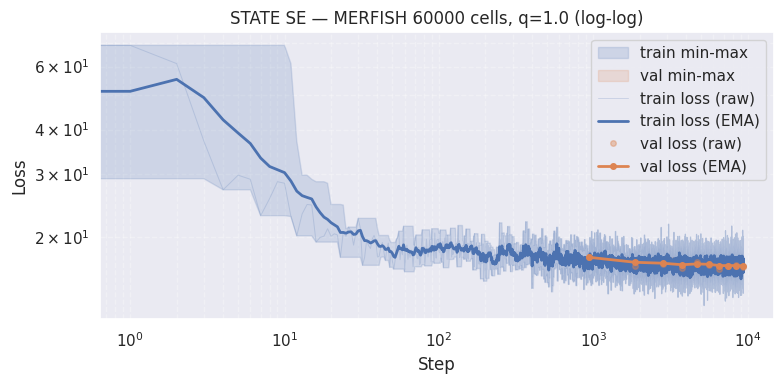

In [4]:
# CSVLogger writes to {checkpoint_dir}/{experiment_name}/version_*/metrics.csv
log_dirs = sorted(glob.glob(
    str(model.checkpoint_dir / f"state_{model.profile_name}" / "version_*")
))
metrics_file = Path(log_dirs[-1]) / "metrics.csv"
print(f"Reading: {metrics_file}")

df = pd.read_csv(metrics_file)
train_loss = df[["step", "trainer/train_loss"]].dropna()
val_loss = df[["step", "validation/val_loss"]].dropna()

# Calculate EMA for train and val loss using pandas (alpha=0.2 by default, can adjust)
train_loss["ema_train_loss"] = train_loss["trainer/train_loss"].ewm(alpha=0.2).mean()
val_loss["ema_val_loss"] = val_loss["validation/val_loss"].ewm(alpha=0.2).mean()

# Calculate min and max in rolling windows for bands (window=10 as a start, can adjust)
train_win = 10
train_loss["min_train"] = train_loss["trainer/train_loss"].rolling(train_win, min_periods=1).min()
train_loss["max_train"] = train_loss["trainer/train_loss"].rolling(train_win, min_periods=1).max()
val_win = 5
val_loss["min_val"] = val_loss["validation/val_loss"].rolling(val_win, min_periods=1).min()
val_loss["max_val"] = val_loss["validation/val_loss"].rolling(val_win, min_periods=1).max()

fig, ax = plt.subplots(figsize=(8, 4))

# Shaded min-max bands for train and val loss
ax.fill_between(train_loss["step"], train_loss["min_train"], train_loss["max_train"], 
                color="C0", alpha=0.18, label="train min-max")
ax.fill_between(val_loss["step"], val_loss["min_val"], val_loss["max_val"], 
                color="C1", alpha=0.18, label="val min-max")

# Plot raw and EMA lines
ax.plot(train_loss["step"], train_loss["trainer/train_loss"],
        label="train loss (raw)", alpha=0.2, linewidth=0.7)
ax.plot(train_loss["step"], train_loss["ema_train_loss"],
        label="train loss (EMA)", color="C0", linewidth=2)
ax.plot(val_loss["step"], val_loss["validation/val_loss"],
        "o", label="val loss (raw)", markersize=4, alpha=0.4)
ax.plot(val_loss["step"], val_loss["ema_val_loss"],
        "o-", label="val loss (EMA)", color="C1", markersize=4, linewidth=2)

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title(f"STATE SE — MERFISH {SIZE} cells, q={QUALITY} (log-log)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3, which="both", linestyle='--')
fig.tight_layout()
plt.show()

## 3. Embed test set

In [5]:
embeddings = model.embed()
print(f"Embeddings shape: {embeddings.shape}")

  Using checkpoint: /home/igor/noise_scaling/data/merfish/60000/1.0/results/State/model/checkpoints/state_scaling_merfish_60000_1_0/last.ckpt
  Running: /home/igor/miniconda3/envs/state/bin/python -m state emb transform --checkpoint /home/igor/noise_scaling/data/merfish/60000/1.0/results/State/model/checkpoints/state_scaling_merfish_60000_1_0/last.ckpt --input /home/igor/noise_scaling/data/merfish/test/1.0/preprocessed/preprocessed.h5ad --output /home/igor/noise_scaling/data/merfish/60000/1.0/results/State/model/embeddings.npy


INFO:state._cli._emb._transform:Using model checkpoint: /home/igor/noise_scaling/data/merfish/60000/1.0/results/State/model/checkpoints/state_scaling_merfish_60000_1_0/last.ckpt
INFO:state._cli._emb._transform:Creating inference object
INFO:state._cli._emb._transform:Loading model from checkpoint: /home/igor/noise_scaling/data/merfish/60000/1.0/results/State/model/checkpoints/state_scaling_merfish_60000_1_0/last.ckpt
INFO:state._cli._emb._transform:Created output directory: /home/igor/noise_scaling/data/merfish/60000/1.0/results/State/model
INFO:state._cli._emb._transform:Computing embeddings for /home/igor/noise_scaling/data/merfish/test/1.0/preprocessed/preprocessed.h5ad
INFO:state._cli._emb._transform:Output will be saved to /home/igor/noise_scaling/data/merfish/60000/1.0/results/State/model/embeddings.npy as a NumPy array of embeddings only (no embedded .h5ad will be written)
INFO:state.emb.inference:Auto-detected gene column: var.index (overlap: 483/483 protein embeddings, 100.0% 

!!! 483 genes mapped to embedding file (out of 483)


Encoding: 100%|██████████| 1224/1224 [02:35<00:00,  7.90it/s]
INFO:state._cli._emb._transform:Saved embeddings matrix with shape (78329, 256) to /home/igor/noise_scaling/data/merfish/60000/1.0/results/State/model/embeddings.npy
INFO:state._cli._emb._transform:Embedding computation completed successfully!


  Embeddings: (78329, 256)
Embeddings shape: (78329, 256)


## 4. Compute LMI mutual information

In [6]:
mi_results = model.mutual_information(max_epochs=300)
print("\nLMI results:")
for signal, mi in mi_results.items():
    print(f"  {signal}: {mi:.5f}")

Using GPU for LMI computation (device 0 visible as cuda:0)
Found 3 quality-specific signal files: ['Y_cur_idx_1.0.csv', 'Y_ng_idx_1.0.csv', 'Y_ng_idx_1.0_geneformer.csv']
using signal file /home/igor/noise_scaling/data/merfish/test/1.0/signals/Y_cur_idx_1.0.csv
epoch 140 (of max 300) 🌻🌻🌻🌻 🎉🎉
success! training stopped at epoch 140
final validation loss: 2.166059064865112
State MI for Y_cur_idx_1.0 at merfish quality 1.0 size 60000: 0.07506561186672749
Saving results to /home/igor/noise_scaling/data/merfish/60000/1.0/results/State/model/MI/42/Y_cur_idx_1.0
using signal file /home/igor/noise_scaling/data/merfish/test/1.0/signals/Y_ng_idx_1.0.csv
epoch 144 (of max 300) 🌻🌻🌻🌻 🎉🎉
success! training stopped at epoch 144
final validation loss: 2.162008285522461
State MI for Y_ng_idx_1.0 at merfish quality 1.0 size 60000: 0.02939077479914097
Saving results to /home/igor/noise_scaling/data/merfish/60000/1.0/results/State/model/MI/42/Y_ng_idx_1.0

LMI results:
  Y_cur_idx_1.0.csv: 0.07507
  Y_ng_id

## 5. Compare LMI across methods

In [7]:
# Collect LMI scores from all methods across all available seeds
results_root = base_dir / "results"
algos = ["PCA", "RandomProjection", "SCVI", "Geneformer", "State"]

rows = []
for algo in algos:
    sig = "Y_ng_idx_1.0_geneformer" if algo == "Geneformer" else "Y_ng_idx_1.0"
    mi_base = results_root / algo / "model" / "MI"
    if not mi_base.exists():
        print(f"{algo:20s}  NOT FOUND")
        continue
    for seed_dir in sorted(mi_base.iterdir()):
        mi_file = seed_dir / sig / "lmi_mutual_information.txt"
        if mi_file.exists():
            mi = float(mi_file.read_text().strip())
            rows.append({"Algorithm": algo, "seed": int(seed_dir.name), "LMI (ng_idx)": mi})
            print(f"{algo:20s}  seed={seed_dir.name}  {mi:.5f}")

scores = pd.DataFrame(rows)
scores_agg = (
    scores.groupby("Algorithm")["LMI (ng_idx)"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "mean_lmi", "std": "std_lmi", "count": "n_seeds"})
    .reset_index()
    .sort_values("mean_lmi", ascending=False)
)
scores_agg["std_lmi"] = scores_agg["std_lmi"].fillna(0)
scores_agg

PCA                   seed=1404  1.62044
PCA                   seed=2303  1.59449
PCA                   seed=2701  1.66469
PCA                   seed=42  1.60985
RandomProjection      seed=1404  0.50802
RandomProjection      seed=2303  0.49535
RandomProjection      seed=2701  0.50802
RandomProjection      seed=42  0.50802
SCVI                  seed=1404  1.90138
SCVI                  seed=2303  1.89948
SCVI                  seed=2701  1.88539
SCVI                  seed=42  1.88666
Geneformer            seed=1404  1.12425
Geneformer            seed=2303  1.01388
Geneformer            seed=2701  0.96062
Geneformer            seed=42  1.09990
State                 seed=42  0.02939


,Algorithm,mean_lmi,std_lmi,n_seeds
3,SCVI,1.893228,0.008369,4
1,PCA,1.622367,0.030159,4
0,Geneformer,1.049662,0.075930,4
2,RandomProjection,0.504853,0.006335,4
4,State,0.029390,0.000000,1


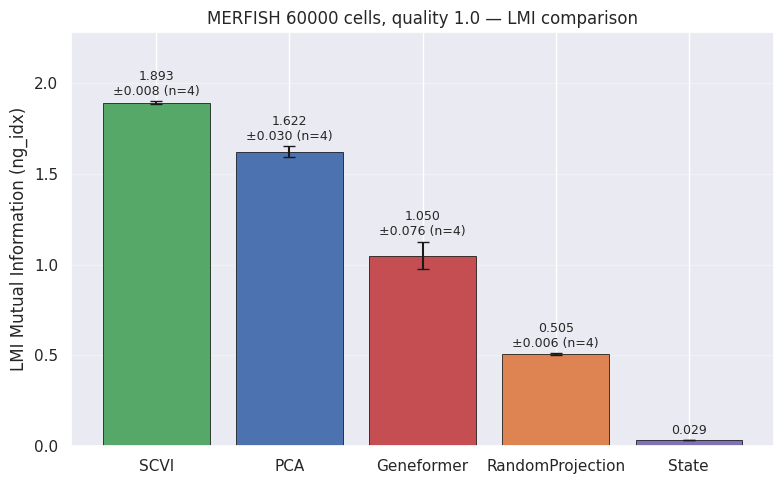

In [8]:
colors = {"PCA": "#4C72B0", "RandomProjection": "#DD8452",
          "SCVI": "#55A868", "Geneformer": "#C44E52", "State": "#8172B3"}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    scores_agg["Algorithm"], scores_agg["mean_lmi"],
    yerr=scores_agg["std_lmi"],
    capsize=4,
    color=[colors.get(a, "#999") for a in scores_agg["Algorithm"]],
    edgecolor="black", linewidth=0.5,
)

for bar, mean, std, n in zip(bars, scores_agg["mean_lmi"], scores_agg["std_lmi"], scores_agg["n_seeds"]):
    label = f"{mean:.3f}"
    if n > 1:
        label += f"\n\u00b1{std:.3f} (n={n})"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.02,
            label, ha="center", va="bottom", fontsize=9)

ax.set_ylabel("LMI Mutual Information (ng_idx)")
ax.set_title(f"MERFISH {SIZE} cells, quality {QUALITY} — LMI comparison")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, (scores_agg["mean_lmi"] + scores_agg["std_lmi"]).max() * 1.2)
fig.tight_layout()
plt.show()

## 6. UMAP of State embeddings

Running UMAP on 10000 cells, 256 dims


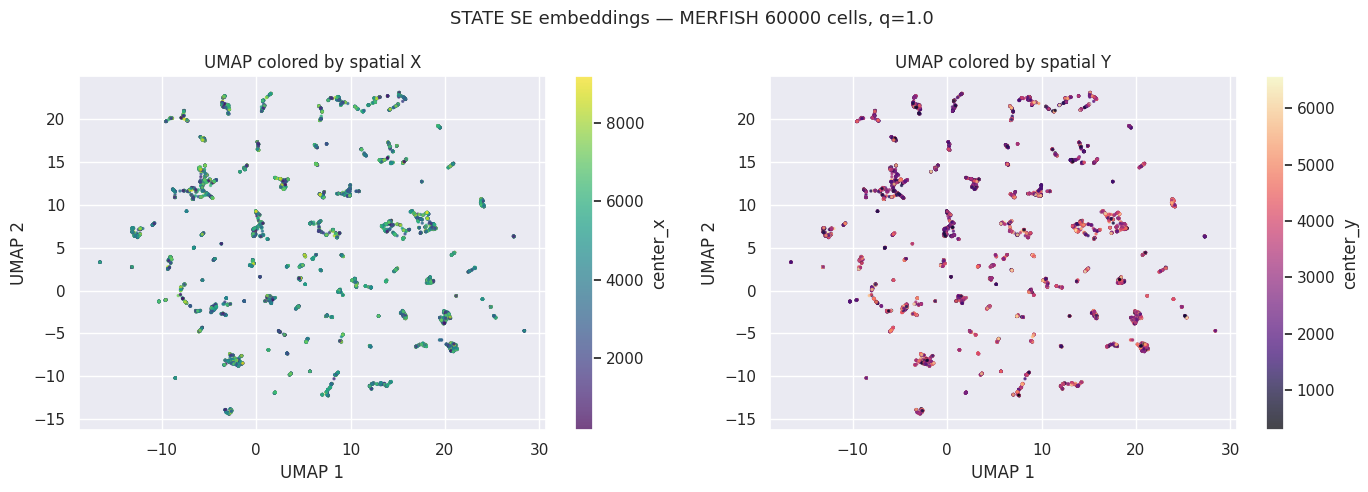

In [9]:
# Load test adata for spatial coordinates
test_h5ad = model.test_data_path / "preprocessed.h5ad"
adata_test = ad.read_h5ad(test_h5ad)

# Subsample for faster UMAP
max_cells = 10_000
if embeddings.shape[0] > max_cells:
    rng = np.random.default_rng(42)
    idx = rng.choice(embeddings.shape[0], max_cells, replace=False)
    emb_sub = embeddings[idx]
    obs_sub = adata_test.obs.iloc[idx]
else:
    emb_sub = embeddings
    obs_sub = adata_test.obs

print(f"Running UMAP on {emb_sub.shape[0]} cells, {emb_sub.shape[1]} dims")
reducer = umap.UMAP(n_components=2, random_state=42, n_jobs=1)
umap_coords = reducer.fit_transform(emb_sub)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(umap_coords[:, 0], umap_coords[:, 1],
                       c=obs_sub["center_x"].values, cmap="viridis", s=2, alpha=0.7)
axes[0].set_title("UMAP colored by spatial X")
axes[0].set_xlabel("UMAP 1"); axes[0].set_ylabel("UMAP 2")
plt.colorbar(sc0, ax=axes[0], label="center_x")

sc1 = axes[1].scatter(umap_coords[:, 0], umap_coords[:, 1],
                       c=obs_sub["center_y"].values, cmap="magma", s=2, alpha=0.7)
axes[1].set_title("UMAP colored by spatial Y")
axes[1].set_xlabel("UMAP 1"); axes[1].set_ylabel("UMAP 2")
plt.colorbar(sc1, ax=axes[1], label="center_y")

fig.suptitle(f"STATE SE embeddings — MERFISH {SIZE} cells, q={QUALITY}", fontsize=13)
fig.tight_layout()
plt.show()

## 7. Save manual pipeline results for comparison

In [10]:
# Save LMI from the manual run above
manual_mi = dict(mi_results)
manual_embeddings = embeddings.copy()
print("Manual pipeline results saved:")
for signal, mi in manual_mi.items():
    print(f"  {signal}: {mi:.5f}")
print(f"  embeddings shape: {manual_embeddings.shape}")

Manual pipeline results saved:
  Y_cur_idx_1.0.csv: 0.07507
  Y_ng_idx_1.0.csv: 0.02939
  embeddings shape: (78329, 256)


## 8. Run end-to-end via `Experiments.single_job()`

Same pipeline (train, embed, LMI) using the `Experiments` abstraction from `run_state_test.py`.

In [11]:
import time
from scaling_laws.prepare.data import Experiments

experiments = Experiments(
    datasets=[DATASET],
    sizes=[SIZE],
    qualities=[QUALITY],
    algos=["State"],
    path_to_data_dir=str(DATA_DIR),
    signal_columns=["cur_idx"],
    device=DEVICE,
    seed=SEED,
)

t_start = time.time()

experiments.single_job(
    dataset=DATASET,
    size=SIZE,
    quality=QUALITY,
    algo="State",
    max_epochs=10,
    early_stopping_patience=3,
    device=DEVICE,
    retrain=True,
    reembed=True,
    recompute_mutual_information=True,
)

t_elapsed = time.time() - t_start
print(f"\nExperiments.single_job() completed in {t_elapsed:.1f}s ({t_elapsed/60:.1f} min)")

Running State for merfish with 60000 cells and 1.0 quality on device 0 (using max_epochs=10 and early_stopping_patience=3)
Using GPU 0 (visible as cuda:0)
Running State for merfish with 60000 cells and 1.0 quality on device 0 (using max_epochs=10 and early_stopping_patience=3)
  Data: 60000 cells, ~937 batches/epoch, val every 937 steps
  Running: /home/igor/miniconda3/envs/state/bin/python -m state emb fit --conf /home/igor/noise_scaling/data/merfish/60000/1.0/preprocessed/state_data/state_config.yaml embeddings.current=scaling_merfish_60000_1_0 dataset.current=scaling_merfish_60000_1_0 dataset.num_cells=60000 dataset.num_train_workers=4 dataset.num_val_workers=2 dataset.pad_length=512 dataset.P=128 dataset.N=128 dataset.S=128 model.batch_size=64 model.emsize=256 model.d_hid=512 model.nhead=4 model.nlayers=3 model.output_dim=256 model.dataset_correction=false model.dropout=0.02 optimizer.max_lr=0.001 optimizer.gradient_accumulation_steps=1 optimizer.weight_decay=0.001 experiment.name=

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.


INFO:state.emb.train.callbacks:CumulativeFLOPSCallback: Measured FLOPs per  0.00it/s v_num: 0.000it/s 
batch: 902615877504
Epoch 0/9  ━━━━╸━━━━━━━━━━━━━━━ 224/938 0:00:12 • 0:00:38 18.96it/s v_num: 0.000


Exception ignored in: <function WeakValueDictionary.__init__.<locals>.remove at 0x743f2b420040>
Traceback (most recent call last):
  File "/home/igor/miniconda3/envs/state/lib/python3.11/weakref.py", line 105, in remove

Detected KeyboardInterrupt, attempting graceful shutdown ...
    def remove(wr, selfref=ref(self), _atomic_removal=_remove_dead_weakref):

KeyboardInterrupt: 
Exception in thread Thread-1 (_pin_memory_loop):
Traceback (most recent call last):
  File "/home/igor/miniconda3/envs/state/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/home/igor/miniconda3/envs/state/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/home/igor/miniconda3/envs/state/lib/python3.11/site-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/home/igor/miniconda3/envs/state/lib/python3.11/site-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one

KeyboardInterrupt: 

## 9. Compare manual vs `Experiments.single_job()` results

In [ ]:
# Load results produced by Experiments.single_job()
exp_emb_path = base_dir / "results" / "State" / "model" / "embeddings.csv"
exp_embeddings = pd.read_csv(exp_emb_path).values

exp_mi = {}
mi_dir = base_dir / "results" / "State" / "model" / "MI" / str(SEED)
for mi_file in sorted(mi_dir.rglob("lmi_mutual_information.txt")):
    signal_name = mi_file.parent.name
    exp_mi[signal_name] = float(mi_file.read_text().strip())

print("=== Experiments.single_job() results ===")
for signal, mi in exp_mi.items():
    print(f"  {signal}: {mi:.5f}")
print(f"  embeddings shape: {exp_embeddings.shape}")

# Compare
print("\n=== Comparison ===")
print(f"{'Signal':<30s} {'Manual':>10s} {'Experiments':>12s} {'Diff':>10s}")
print("-" * 65)
for signal in sorted(set(list(manual_mi.keys()) + list(exp_mi.keys()))):
    m = manual_mi.get(signal, float("nan"))
    e = exp_mi.get(signal, float("nan"))
    print(f"{signal:<30s} {m:>10.5f} {e:>12.5f} {e - m:>+10.5f}")

print(f"\nEmbeddings match shape: {manual_embeddings.shape == exp_embeddings.shape}")